In [1]:
import os
import pandas as pd
import numpy as np
import torch
import librosa
from datasets import Dataset
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split

In [2]:
PATH_TO_FMA_SMALL = r"C:\Users\PC\Desktop\eksploracje\fma_small"
PATH_TO_TRACKS_CSV = r"C:\Users\PC\Desktop\eksploracje\Music_Genres_Classification\tracks.csv"
MODEL_ID = "adhityamw11/distilhubert-finetuned_distillhubert-ravdess"

In [3]:
paths = {}
for root, dirs, files in os.walk(PATH_TO_FMA_SMALL):
    for file in files:
        if file.endswith(".mp3"):
            try:
                track_id = int(file.split(".")[0])
                paths[track_id] = os.path.join(root, file)
            except: continue

print(f"Znaleziono {len(paths)} plików MP3.")

tracks = pd.read_csv(PATH_TO_TRACKS_CSV, index_col=0, header=[0, 1])
keep_tracks = tracks[tracks[('set', 'subset')] == 'small']
df = keep_tracks[('track', 'genre_top')].reset_index()
df.columns = ['track_id', 'genre']

df['path'] = df['track_id'].map(paths)
df = df.dropna(subset=['path']).reset_index(drop=True)

genres = sorted(df['genre'].unique().tolist())
label2id = {label: i for i, label in enumerate(genres)}
id2label = {i: label for i, label in enumerate(genres)}
df['label'] = df['genre'].map(label2id)

print(f"Załadowano {len(df)} utworów z {len(genres)} gatunków.")

Znaleziono 8000 plików MP3.
Załadowano 8000 utworów z 8 gatunków.


In [4]:
import torch
print(f"Czy PyTorch działa? Tak!")
print(f"Czy widzę GPU? {'TAK!' if torch.cuda.is_available() else 'Nie :('}")
if torch.cuda.is_available():
    print(f"Twoja karta to: {torch.cuda.get_device_name(0)}")

Czy PyTorch działa? Tak!
Czy widzę GPU? TAK!
Twoja karta to: NVIDIA GeForce GTX 1070 Ti


In [5]:
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_ID,
    num_labels=len(genres),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

In [6]:
raw_dataset = Dataset.from_pandas(df[['path', 'label']])

def preprocess_function(examples):
    audio_arrays = []
    for path in examples["path"]:
        try:
            y, _ = librosa.load(path, sr=16000, duration=10)
            audio_arrays.append(y)
        except:
            audio_arrays.append(np.zeros(16000 * 10))

    inputs = feature_extractor(
        audio_arrays, 
        sampling_rate=16000, 
        max_length=16000 * 10,
        truncation=True,
        padding="max_length",
        return_tensors="pt"
    )
    return inputs

encoded_dataset = raw_dataset.map(
    preprocess_function, 
    batched=True, 
    batch_size=4, 
    remove_columns=["path"]
)

train_test = encoded_dataset.train_test_split(test_size=0.1)


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

C:\Users\PC\AppData\Local\Temp\ipykernel_7364\3169691770.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=16000, duration=10)
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [7]:
print("Uruchamianie treningu ...")

training_args = TrainingArguments(
    output_dir="./wyniki_modelu_muzycznego",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=4, 
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
    fp16=True, 
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"],
    processing_class=feature_extractor,
)

# START UCZENIA
trainer.train()

# ZAPISANIE MODELU
model.save_pretrained("./finalny_model_muzyczny")
feature_extractor.save_pretrained("./finalny_model_muzyczny")
print("Trening zakończony pomyślnie. Model zapisany w folderze 'finalny_model_muzyczny'.")

Uruchamianie treningu ...


Epoch,Training Loss,Validation Loss
1,1.342715,1.290688
2,1.032539,1.241140
3,0.762702,1.314210


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Trening zakończony pomyślnie. Model zapisany w folderze 'finalny_model_muzyczny'.


               precision    recall  f1-score   support

   Electronic       0.60      0.64      0.62       101
 Experimental       0.47      0.41      0.44        90
         Folk       0.56      0.52      0.54        95
      Hip-Hop       0.73      0.72      0.72        96
 Instrumental       0.49      0.61      0.54        94
International       0.66      0.68      0.67        96
          Pop       0.31      0.25      0.28       100
         Rock       0.65      0.70      0.67       128

     accuracy                           0.57       800
    macro avg       0.56      0.56      0.56       800
 weighted avg       0.56      0.57      0.56       800



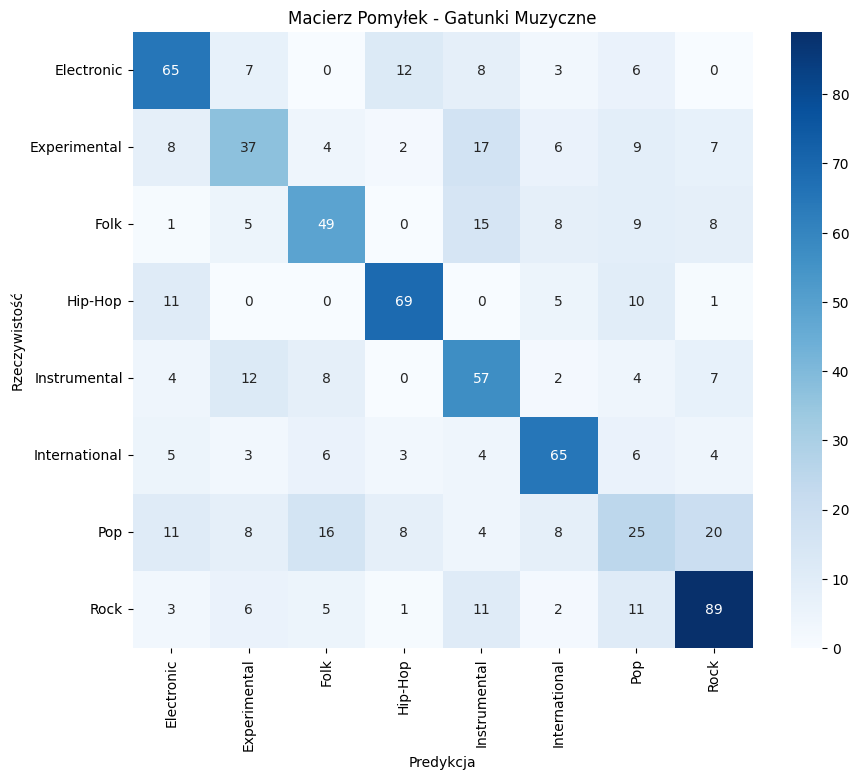

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

predictions = trainer.predict(train_test["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

report = classification_report(y_true, y_pred, target_names=genres)
print(report)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=genres, yticklabels=genres, cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywistość')
plt.title('Macierz Pomyłek - Gatunki Muzyczne')
plt.show()